In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive connected successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive connected successfully!


# **US Baby Names 1880–2010**
#  The frequency of baby names from 1880 to 2010 in US

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ***Introduction***

**The project focuses on analyzing baby name data from the United States, along the years 1880 to 2010.**

**The dataset, provided by the U.S. Social Security Administration.**

**This dataset has multiple files, each file contains records of baby names given in that year, each file contains 3 columns (name, gender, number of births associated with each name) and later I added a column 'year'.**


********************************************

**The goal of this project is to explore and visualize naming trends,popularity, gender diversity, and sociocultural influences, we can understand how social, cultural, and political events influence name popularity and observe shifts naming styles in genders.**




*******************************************
*******************************************

# ***Load and concatenate the data from 1880 to 2010***

In [ ]:
# As I mentioned before, the dataset is split into files by year so we need to:
# 1. Then we combine them into a single table containing the name, gender, number of births
# 2. add a year column
years_frame = []

for year in range(1880, 2011):
    # Corrected path with single slashes
    path = f'/content/drive/MyDrive/datasets/babynames/yob{year}.txt'
    df = pd.read_csv(path, names=["name", "gender", "births"])

    # Add a column for the year
    df["year"] = year
    # Append the frame only once
    years_frame.append(df)

# Concatenate df's into a single DataFrame:
names = pd.concat(years_frame, ignore_index=True) # discards the indexes from each DataFrame, assigning a new default index
names.head(10)

,name,gender,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
5,Margaret,F,1578,1880
6,Ida,F,1472,1880
7,Alice,F,1414,1880
8,Bertha,F,1320,1880
9,Sarah,F,1288,1880


# ***Overlook***

In [ ]:
print(names.head())
print("*"*60)
print(names.info())
print("*"*60)
print(names.describe())

        name gender  births  year
0       Mary      F    7065  1880
1       Anna      F    2604  1880
2       Emma      F    2003  1880
3  Elizabeth      F    1939  1880
4     Minnie      F    1746  1880
************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1690784 entries, 0 to 1690783
Data columns (total 4 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   name    1690784 non-null  object
 1   gender  1690784 non-null  object
 2   births  1690784 non-null  int64 
 3   year    1690784 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 51.6+ MB
None
************************************************************
             births          year
count  1.690784e+06  1.690784e+06
mean   1.906824e+02  1.969454e+03
std    1.615900e+03  3.282353e+01
min    5.000000e+00  1.880000e+03
25%    7.000000e+00  1.946000e+03
50%    1.200000e+01  1.979000e+03
75%    3.200000e+01  1.997000e+03
max   

# ***Deal with missing values in each column***

In [ ]:
# Check Missing data to fill it if exist
if names.isnull().any().any(): # check column,column if itd empty and then check values in any column
  names.fillna(0, inplace=True) # inplace=True fill impacts on  the object referance not a copy
  print("Missing Data Filled")
else:
  print("No Missing Data")

No Missing Data


# ***Cleaning names***
**Remove spaces from names in 'name' column**

In [ ]:
names["name"] = names["name"].str.strip().str.title()

# ***Total Births by Gender and Year analysis***
**Aggregating the births data at the year and gender level**

/tmp/ipython-input-43-1590742510.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = names.pivot_table("births", index="year",columns="gender", aggfunc=sum)


gender        F        M
year                    
2006    1896468  2050234
2007    1916888  2069242
2008    1883645  2032310
2009    1827643  1973359
2010    1759010  1898382


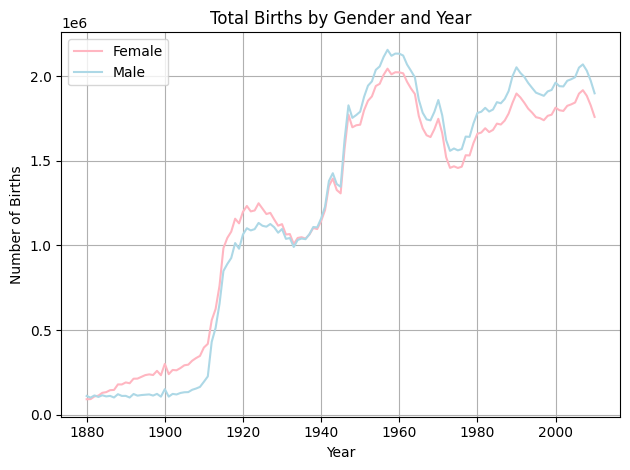

In [ ]:
total_births = names.pivot_table("births", index="year",columns="gender", aggfunc=sum)
print(total_births.tail())


sns.lineplot(x=total_births.index, y=total_births["F"], label="Female", color="lightpink")
sns.lineplot(x=total_births.index, y=total_births["M"], label="Male", color="lightblue")
plt.title("Total Births by Gender and Year")
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ***The percentage of each name per year/sex***
* I calculated the percentage of each name compared to the total number of births in the same year and gender.
* This allows us to compare names regardless of the total number of births.

In [ ]:
# Explain :
# Add a column (per)  = times of a name / all births in same year and gender
# apply fun to each class
def add_prop(group):
  group["prop"] = group["births"] / group["births"].sum()
  return group

# Reset the index before grouping to ensure 'year' is treated only as a column and keep defult index as indexes not a column
names = names.reset_index(drop=True)

if "index" in names.columns:
    names = names.drop(columns=["index"])

names = names.groupby(["year", "gender"], group_keys=False).apply(add_prop)
print(names.head())

        name gender  births  year      prop
0       Mary      F    7065  1880  0.077643
1       Anna      F    2604  1880  0.028618
2       Emma      F    2003  1880  0.022013
3  Elizabeth      F    1939  1880  0.021309
4     Minnie      F    1746  1880  0.019188


/tmp/ipython-input-44-820441794.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  names = names.groupby(["year", "gender"], group_keys=False).apply(add_prop)


# ***Ensure that the sum of all percenteges = 1***

In [ ]:
# Explain :
# group names dataframe into groups based on year and gender and choose col per and apply sum on it and round float to 5(خانات عشرية )
# for all per in each group == 1

check = names.groupby(["year", "gender"])["prop"].sum().round(5)
print((check == 1).all())

True


# ***Extract the top 1000 names per year and sex***
 We choose the 1000 most used names for each year and gender.

In [ ]:
# Explain :
# sort each group descending order based on births
# apply this fun on each group


def top_1000(group):
  return group.sort_values("births", ascending=False)[:1000]


top1000 = names.groupby(["year","gender"], group_keys=False).apply(top_1000).reset_index(drop=True)
print(top1000.head())

        name gender  births  year      prop
0       Mary      F    7065  1880  0.077643
1       Anna      F    2604  1880  0.028618
2       Emma      F    2003  1880  0.022013
3  Elizabeth      F    1939  1880  0.021309
4     Minnie      F    1746  1880  0.019188


/tmp/ipython-input-46-2700917329.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1000 = names.groupby(["year","gender"], group_keys=False).apply(top_1000).reset_index(drop=True)


# ***Top 5 frequant Names trend in general***


name
James      5072771
John       5061897
Robert     4788050
Michael    4265373
Mary       4119074
Name: births, dtype: int64


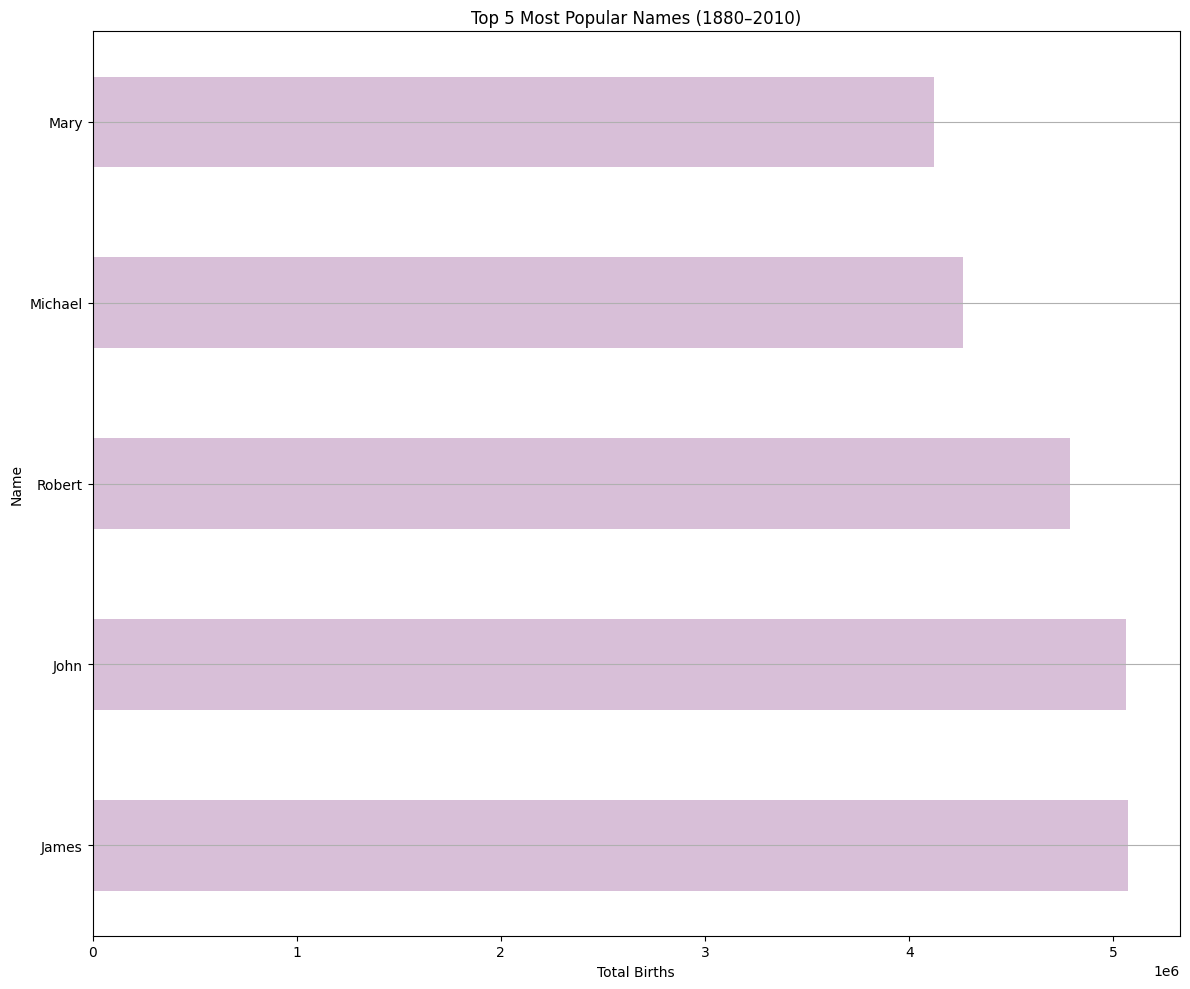

In [ ]:
top_names = names.groupby(["name"])["births"].sum().sort_values(ascending=False).head(5)
print(top_names)

top_names.plot(kind="barh", color="thistle", figsize=(12, 10))
plt.title("Top 5 Most Popular Names (1880–2010)")
plt.xlabel("Total Births")
plt.ylabel("Name")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


# ***Name trend over years (for some names)***

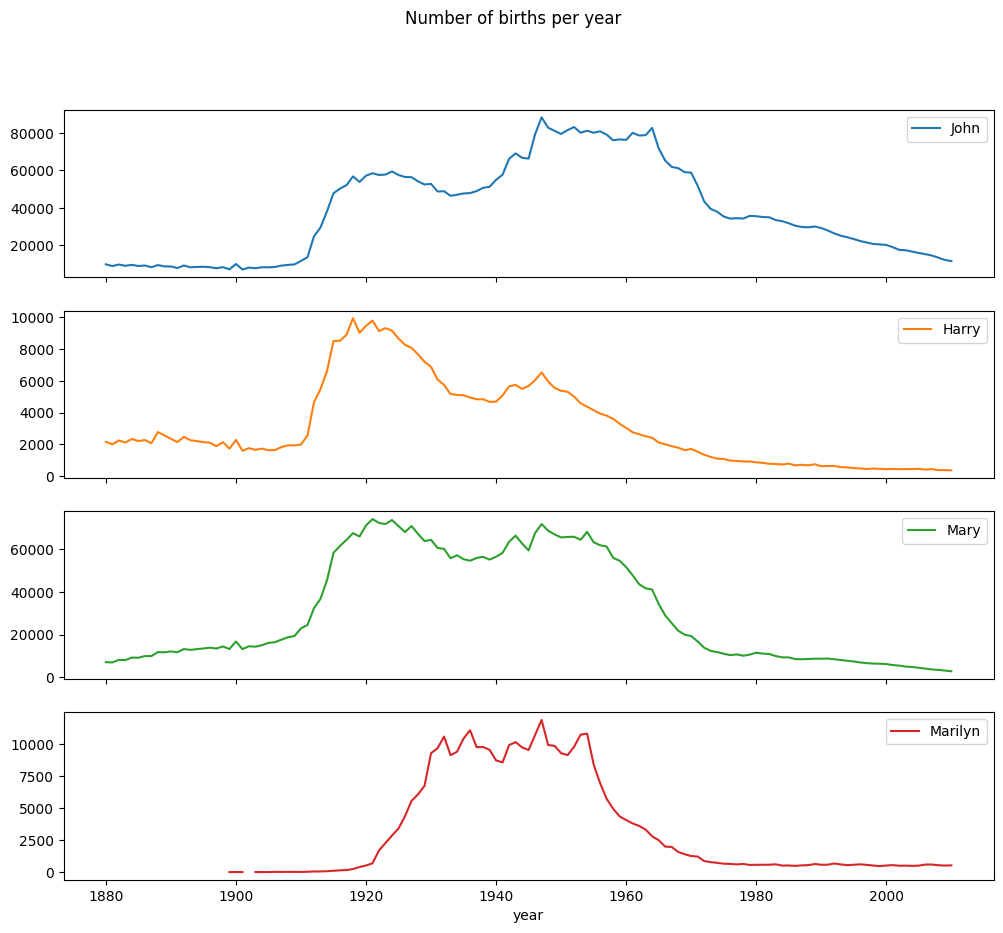

In [ ]:
total_births = names.reset_index(drop=True).pivot_table("births", index="year", columns="name", aggfunc="sum")
subset = total_births[["John", "Harry", "Mary", "Marilyn"]]
subset.plot(subplots=True, figsize=(12, 10), title="Number of births per year") # plot each column
plt.legend(loc='upper right')
plt.show()

# ***The most famous names for boys and girls***

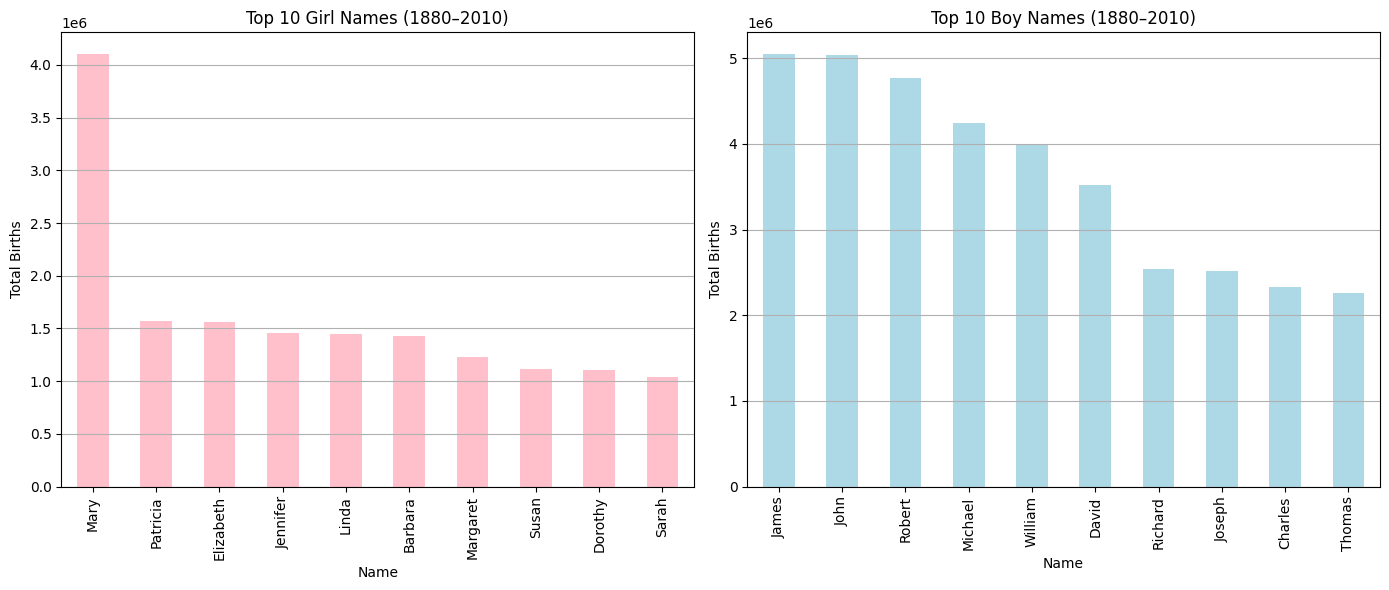

In [ ]:
# female names (top 10)
top_female = names[names["gender"] == "F"].groupby("name")["births"].sum().sort_values(ascending=False).head(10)

# male names (top 10)
top_male = names[names["gender"] == "M"].groupby("name")["births"].sum().sort_values(ascending=False).head(10)

# Plotting both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_female.plot(kind="bar", ax=axes[0], color="pink", title="Top 10 Girl Names (1880–2010)")
axes[0].set_ylabel("Total Births")
axes[0].set_xlabel("Name")
axes[0].grid(axis="y")

top_male.plot(kind="bar", ax=axes[1], color="lightblue", title="Top 10 Boy Names (1880–2010)")
axes[1].set_ylabel("Total Births")
axes[1].set_xlabel("Name")
axes[1].grid(axis="y")


#لترتيب العناصر داخل الشكل النهائي. لا تتداخل العناصر
plt.tight_layout()
plt.show()

# ***Naming Diversity***
***How many different names were used? Do people still give their children the old, popular names? Or are they choosing more new names?***

# ***Let's See:***

# ***The Dominance of Top 1000 Mames in Births***
**The representation of the most popular names (Top 1000) in terms of percentage of total births in each year and for each gender.**

Text(1940, 0.95, 'Start noticing more diversity in names over time')

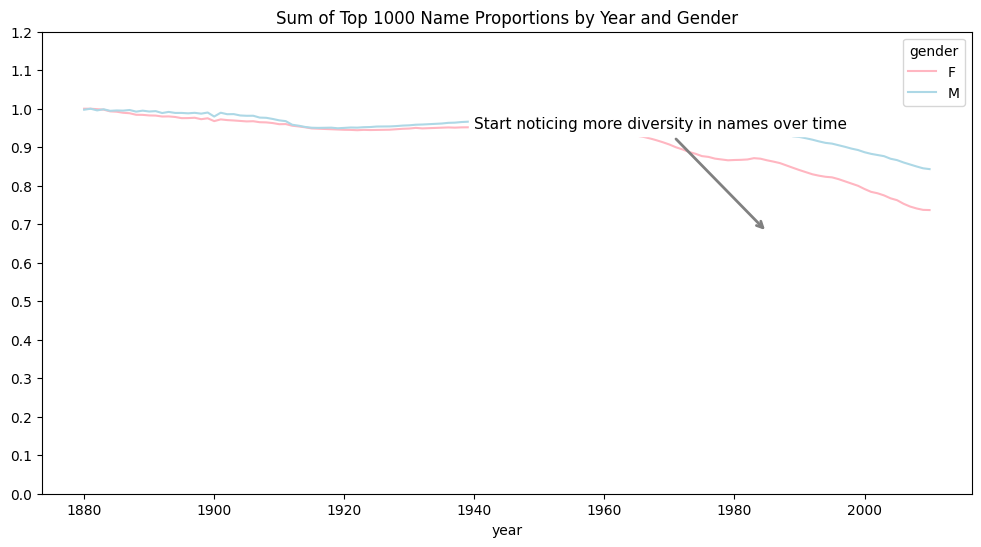

In [ ]:
# قياس مدى هيمنة top 1000 اسم على الولادات
# back to top 1000 name
table = top1000.pivot_table("prop", index="year", columns="gender", aggfunc="sum") # نستخدم النسبة prop لنحسب مجموع نسب الـ 1000 اسم لكل سنة وجنس.
ax = table.plot(
    title="Sum of Top 1000 Name Proportions by Year and Gender",
    figsize=(12, 6),
    color=["lightpink", "lightblue"],
    yticks=np.linspace(0, 1.2, 13),
    xticks=range(1880, 2020, 20)
)
ax.annotate(
    "Start noticing more diversity in names over time",
    xy=(1985, 0.68),
    xytext=(1940, 0.95),
    arrowprops=dict(arrowstyle="->", color="gray", lw=2),
    fontsize=11,
    backgroundcolor='white'
)

**notice: the diversity is increasing by times**

# ***1. Comparsion between name popularity to cover the top 50% of births***
* how many different names represent 50% of the number of births in **(2010, 1990)**.
* A decrease in the number indicates a lack of diversity, while an increase indicates a prevalence of names.



***starting with random years:***

In [ ]:
# For 2011
boys = names[names["gender"] == "M"]
girls = names[names["gender"] == "F"]

df = boys[boys["year"] == 2010]
in2010 = df["prop"].sort_values(ascending=False).cumsum()
print(" distinct names to cover 50% of the boys in 2010: ",in2010.searchsorted(0.5)+1)

 distinct names to cover 50% of the boys in 2010:  117


In [ ]:
# For 1990
df = boys[boys["year"] == 1900]
in1900 = df.sort_values("prop", ascending=False).prop.cumsum()
print(" distinct names to cover 50% of the boys in 1900: ",in1900.searchsorted(0.5)+1)

 distinct names to cover 50% of the boys in 1900:  25


***for all years:***

/tmp/ipython-input-53-622289417.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  deversity = top1000.groupby(["year", "gender"]).apply(get_quantile_count)


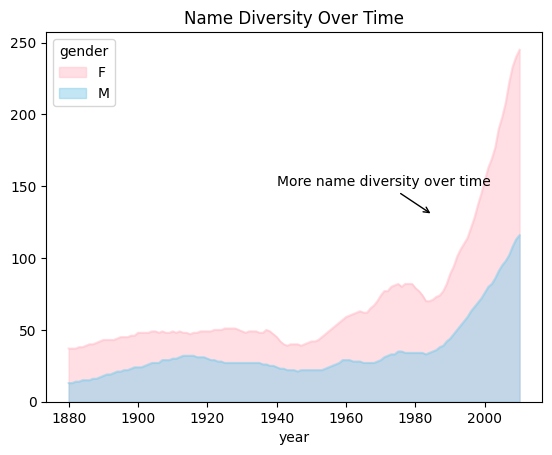

In [ ]:
def get_quantile_count(group, q=0.5):
    group = group.sort_values("prop", ascending=False)
    total = group["prop"].cumsum()
    count = (total <= q).sum()
    return count

deversity = top1000.groupby(["year", "gender"]).apply(get_quantile_count)
deversity = deversity.unstack("gender")
deversity.plot(kind="area", title="Name Diversity Over Time", stacked=False, color=["pink", "skyblue"])
#diversity.plot(title="Number of Popular Names in Top 50%", color=["#FF69B4", "#6495ED"])
plt.annotate("More name diversity over time", xy=(1985, 130), xytext=(1940, 150),
arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)
plt.show()

**In the past, names were few and repetitive.**

**Now, there's greater diversity, especially among girls.**

**This is due to cultural differences and a desire for unique names.**

# ***2.  The “last letter” analysis***
**how the last letters of names have changed over time for both males and females.**

In [ ]:
names["last_letter"] = names["name"].str[-1]
last_letter_table = names.pivot_table("births", index="last_letter", columns=["gender", "year"], aggfunc="sum") #  جدول يبيّن كم عدد الأسماء المنتهية بكل حرف لكل سنة وجنس
subtable = last_letter_table.reindex(columns=[1910, 1960, 2010], level="year").fillna(0) #نختار فقط السنوات الثلاث المهمة للمقارنة.

last_letter_prop = subtable / subtable.sum() #تحويل الأعداد إلى نسب مئوية.
print(last_letter_prop)

gender              F                             M                    
year             1910      1960      2010      1910      1960      2010
last_letter                                                            
a            0.273390  0.341853  0.381240  0.005031  0.002440  0.014980
b            0.000000  0.000343  0.000256  0.002116  0.001834  0.020470
c            0.000013  0.000024  0.000538  0.002482  0.007257  0.012181
d            0.017028  0.001844  0.001482  0.113858  0.122908  0.023387
e            0.336941  0.215133  0.178415  0.147556  0.083853  0.067959
f            0.000000  0.000010  0.000055  0.000783  0.004325  0.001188
g            0.000144  0.000157  0.000374  0.002250  0.009488  0.001404
h            0.051529  0.036224  0.075852  0.045562  0.037907  0.051670
i            0.001526  0.039965  0.031734  0.000844  0.000603  0.022628
j            0.000000  0.000000  0.000090  0.000000  0.000000  0.000769
k            0.000121  0.000156  0.000356  0.036581  0.049384  0

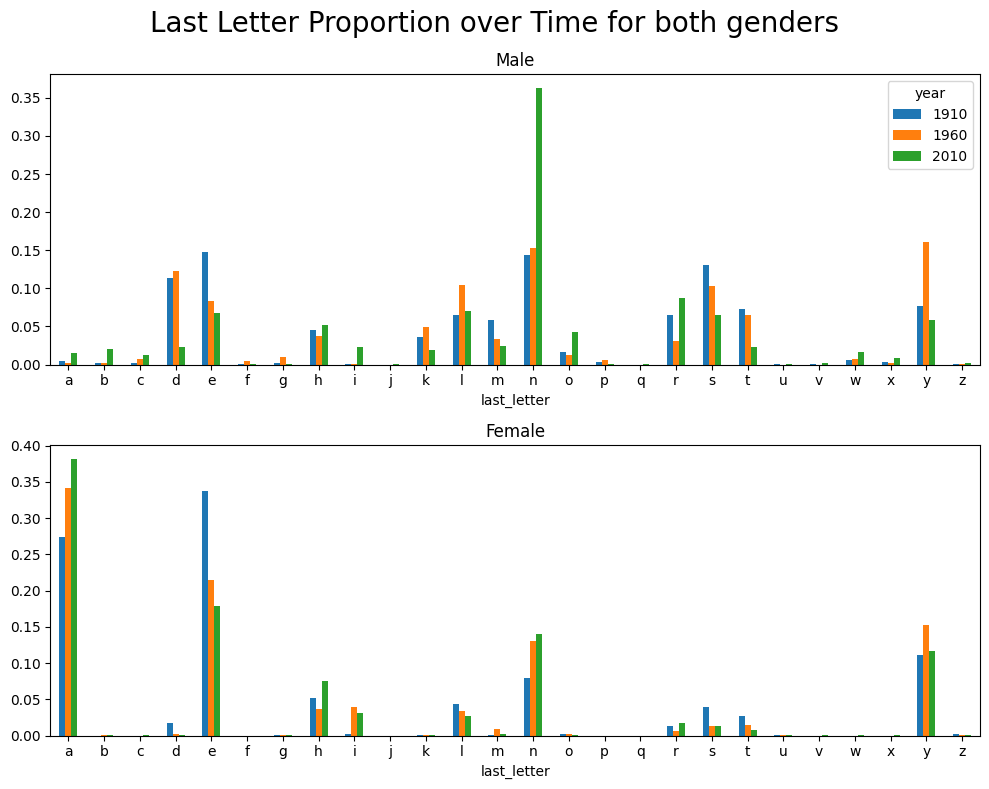

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle("Last Letter Proportion over Time for both genders", fontsize=20)
last_letter_prop["M"].plot(kind="bar", rot=0, ax=axes[0], title="Male")
last_letter_prop["F"].plot(kind="bar",  rot=0, ax=axes[1], title="Female",legend=False)
plt.tight_layout()

# ***3. The “first letter” analysis***

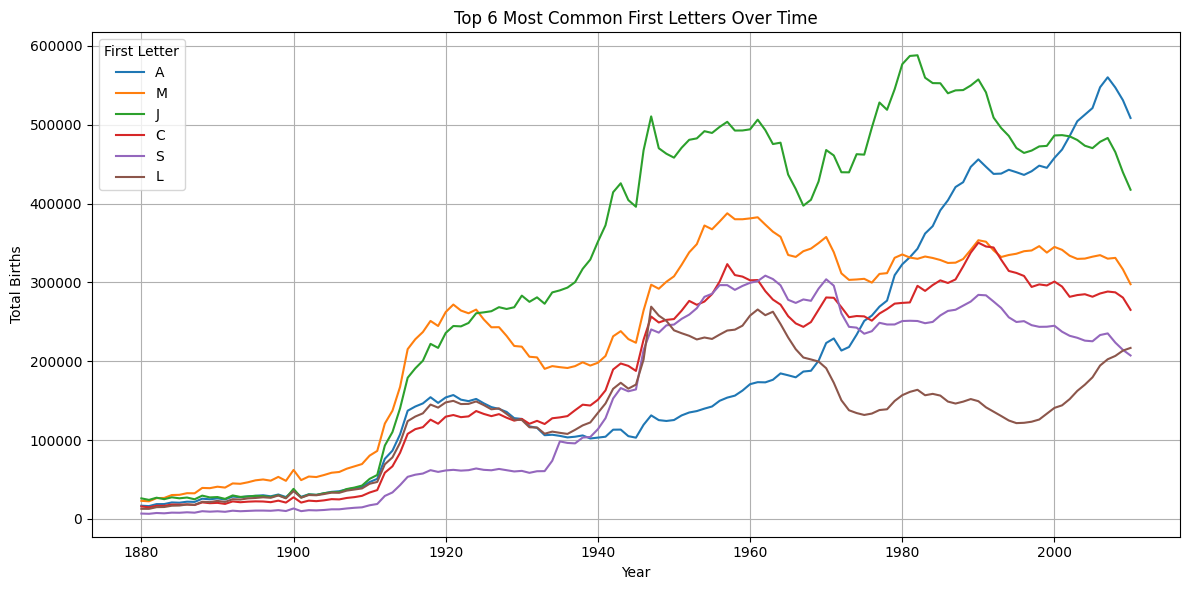

In [ ]:
names["first_letter"] = names["name"].str[0]
first_letter_table = names.pivot_table("births", index="year", columns="first_letter", aggfunc="sum")

# choose top populer 6  letters
top_letters = names["first_letter"].value_counts().head(6).index
filtered_table = first_letter_table[top_letters]


filtered_table.plot(figsize=(12, 6), title="Top 6 Most Common First Letters Over Time")
plt.ylabel("Total Births")
plt.xlabel("Year")
plt.grid(True)
plt.legend(title="First Letter")
plt.tight_layout()
plt.show()

# ***4. popularity of boy's names with ending letters(n, d, y)***

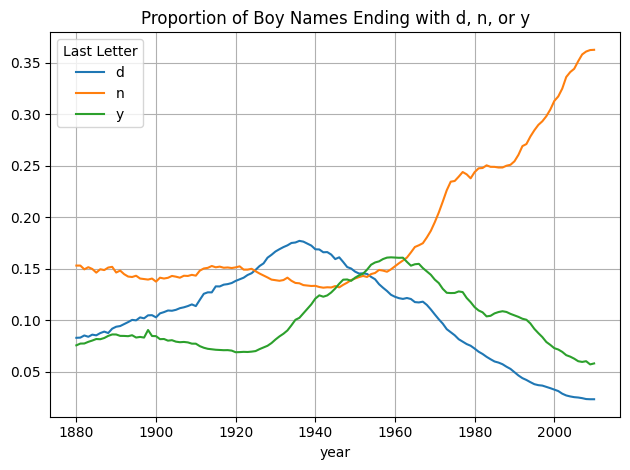

In [ ]:
# هذا يجعل السنوات تظهر على المحور الأفقي والحروف الأخيرة تظهر كخطوط متعددة في الرسم.T

dny_ts = (last_letter_table / last_letter_table.sum()).fillna(0).loc[["d", "n", "y"], "M"].T
dny_ts.plot(title="Proportion of Boy Names Ending with d, n, or y")
plt.legend(title="Last Letter")
plt.grid(True)
plt.tight_layout()
plt.show()

# ***5. Boy names that became girl names (and vice versa)***

Notice names that were more popular with one gender earlier but have become preferred as a name for the other gender over time.
One example is the name **Taylor**.


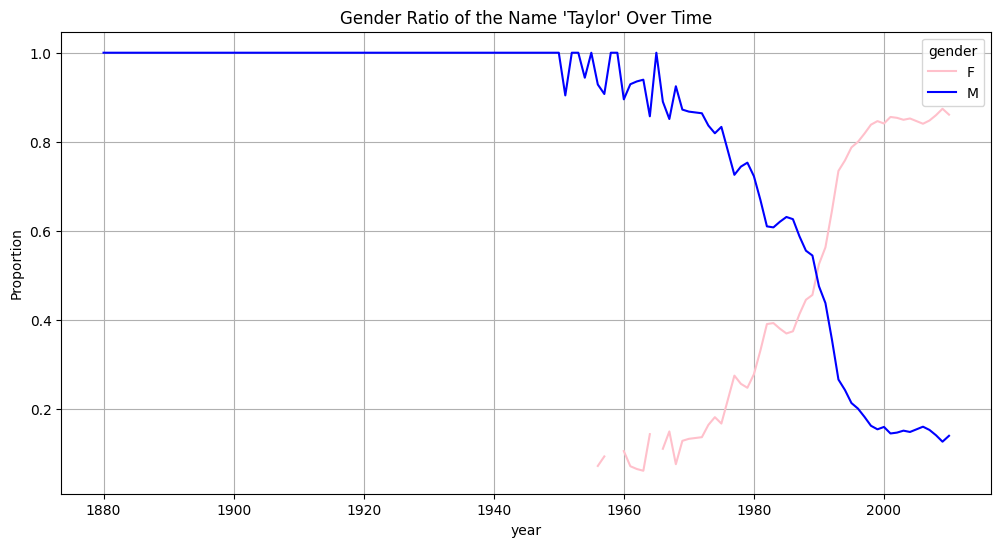

In [ ]:
taylor = names[names["name"] == "Taylor"]

# جدول فيه عدد المواليد لكل السنة وحنس الجنس
taylor_pivot = taylor.pivot_table("births", index="year", columns="gender", aggfunc="sum")

taylor_ratio = taylor_pivot.div(taylor_pivot.sum(axis=1), axis=0)


taylor_ratio.plot(title="Gender Ratio of the Name 'Taylor' Over Time", figsize=(12, 6), style={"M": "blue", "F": "pink"})
plt.ylabel("Proportion")
plt.grid(True)
plt.show()

**Notice: the name Taylor became more populer for girls rather than boys**

# ***Analysis of some names associated with political and social events:***

# ***Analysis of name 'Barack' after 2008***


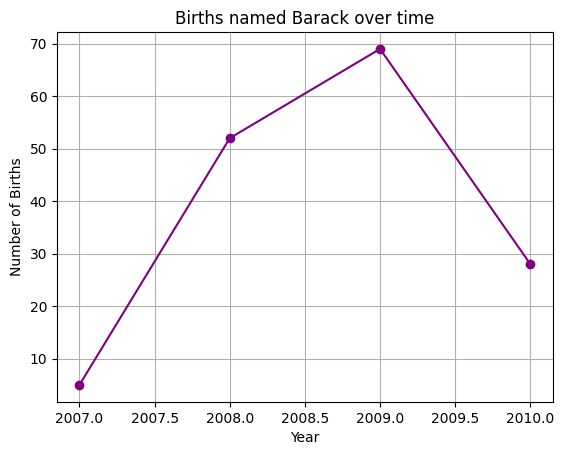

In [ ]:
barack = names[names["name"] == "Barack"]
births_by_year = barack.groupby("year")["births"].sum()
births_by_year.plot(marker="o", color="purple", title="Births named Barack over time")
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.grid(True)
plt.show()

# ***Analysis of name after "Katrina" after 2005***

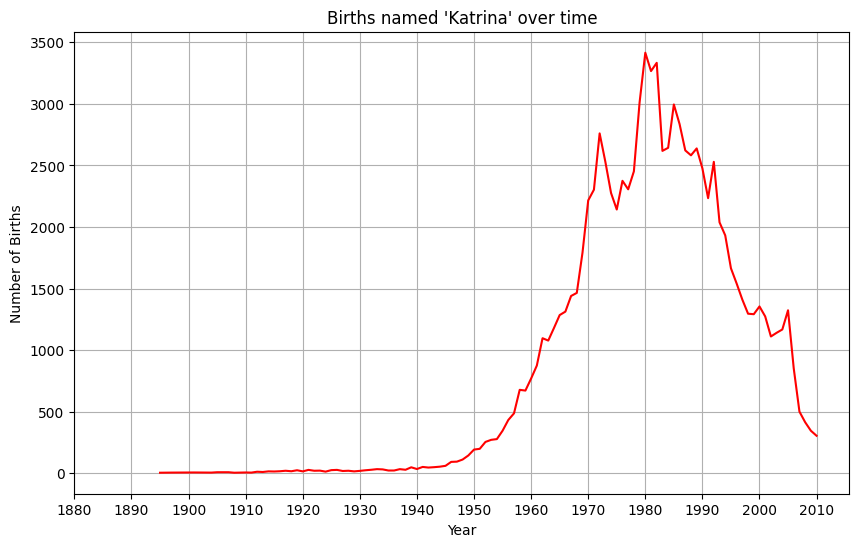

In [ ]:
Katrina = names[names["name"] == "Katrina"]
groups = Katrina.groupby("year")["births"].sum()
groups.plot(color = "red", figsize=(10, 6), title="Births named 'Katrina' over time")
plt.xlabel("Year")
plt.xticks(range(1880, 2011, 10))
plt.ylabel("Number of Births")
plt.grid(True)
plt.show()

# ***Analysis of the name "Diana" after 1981***

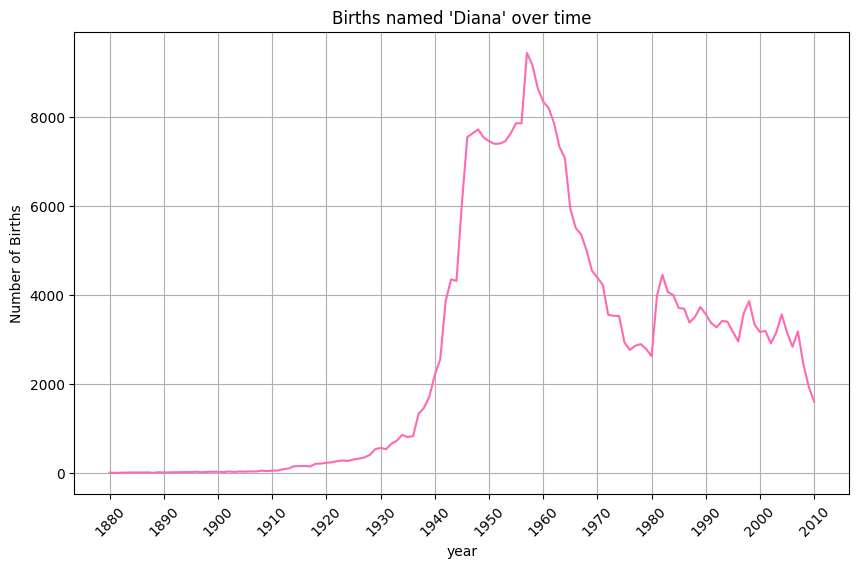

In [ ]:
diana = names[names["name"] == "Diana"]
groups = diana.groupby("year")["births"].sum()
groups.plot(figsize=(10, 6), color = ["hotpink"], title="Births named 'Diana' over time", rot= 45)

plt.xticks(range(1880, 2011, 10))
plt.ylabel("Number of Births")
plt.grid(True)
plt.show()

# ***Number of Births during World War I and II***
| الحدث                  | الفترة      |
| ---------------------- | ----------- |
| الحرب العالمية الأولى  | 1914 – 1918 |
| الحرب العالمية الثانية | 1939 – 1945 |


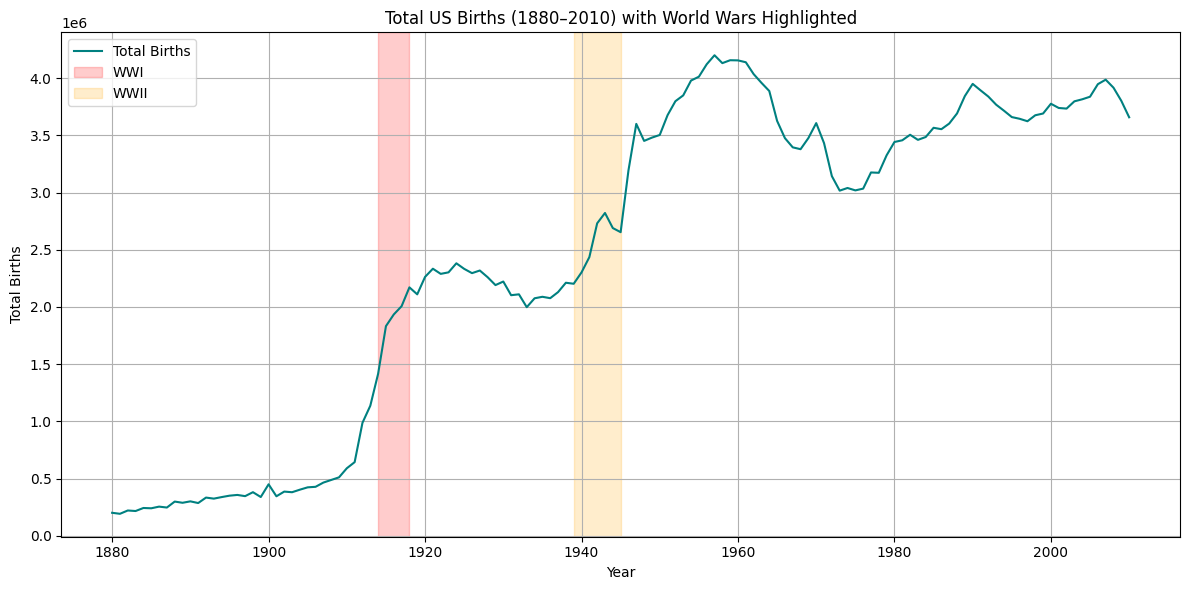

In [ ]:
yearly_births = names.groupby("year")["births"].sum()

plt.figure(figsize=(12, 6))
plt.plot(yearly_births.index, yearly_births.values, color="teal", label="Total Births")

# إبراز فترات الحرب
plt.axvspan(1914, 1918, color="red", alpha=0.2, label="WWI")
plt.axvspan(1939, 1945, color="orange", alpha=0.2, label="WWII")

plt.title("Total US Births (1880–2010) with World Wars Highlighted")
plt.xlabel("Year")
plt.ylabel("Total Births")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ***Average name length analysis***


year  gender
1880  F         5.773885
      M         5.634216
1881  F         5.750533
      M         5.602808
1882  F         5.805447
                  ...   
2008  M         6.065387
2009  F         6.324057
      M         6.059949
2010  F         6.321708
      M         6.048303
Name: name_len, Length: 262, dtype: float64


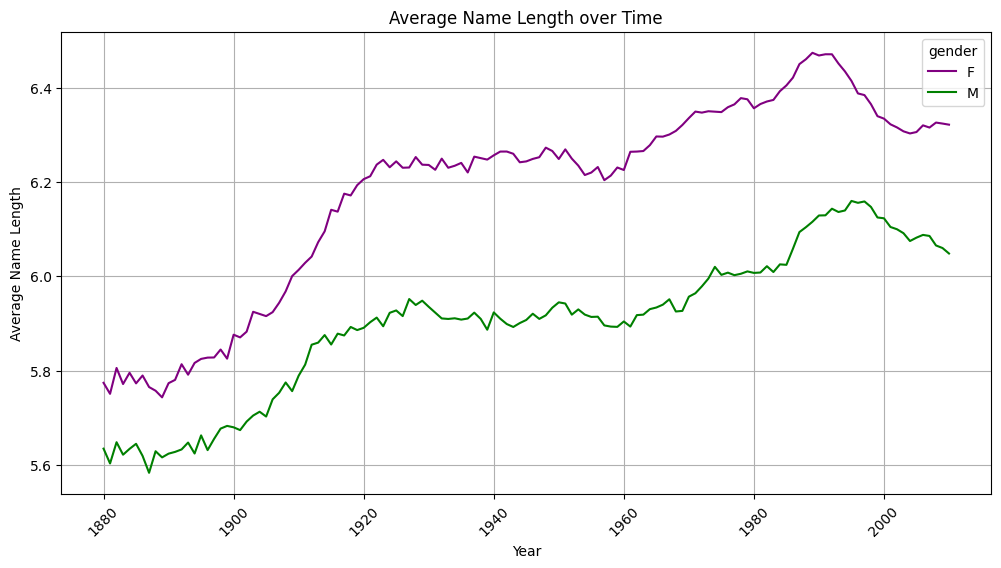

In [ ]:
names["name_len"] = names["name"].str.len()
length_trend = names.groupby(["year", "gender"])["name_len"].mean()
print(length_trend)

length_trend.unstack("gender").plot(title="Average Name Length over Time", figsize=(12, 6), rot= 45, color=["purple", "green"])
plt.xlabel("Year")
plt.ylabel("Average Name Length")
plt.grid(True)
plt.show()

# ***New names appeared after a 1990 analysis***

* We're looking to names that first appeared after 1990.

In [ ]:
new_names = names[names["year"] >= 1990]
top_new = new_names.groupby("name")["births"].sum().sort_values(ascending=False).head(10)
 # get first year the name sappeared

print("Popular names since 1990:")
print(top_new)


Popular names since 1990:
name
Michael        732172
Jacob          594453
Matthew        587795
Christopher    578655
Joshua         577169
Daniel         492556
Andrew         489982
Emily          475575
Joseph         469382
Nicholas       463113
Name: births, dtype: int64


# ***Analysis of names starting with the letter A***

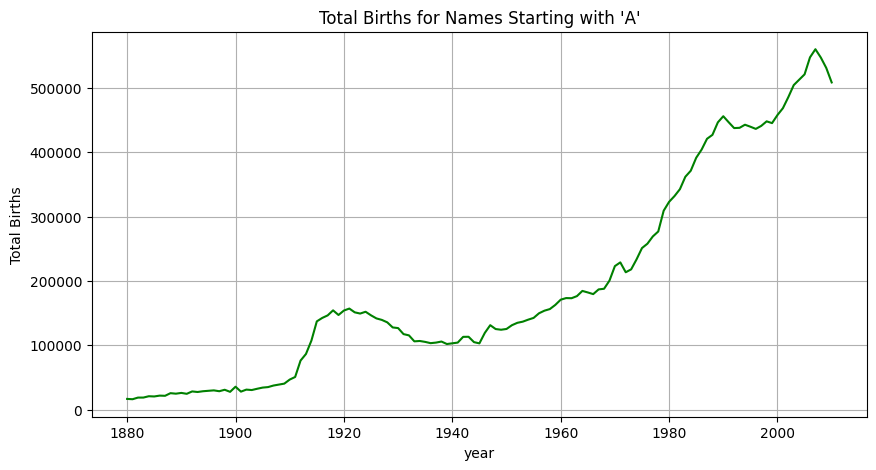

In [ ]:
names_A = names[names["name"].str.startswith("A")]
a_counts = names_A.groupby("year")["births"].sum()

a_counts.plot(title="Total Births for Names Starting with 'A'", figsize=(10,5), color="green")
plt.ylabel("Total Births")
plt.grid(True)
plt.show()

# ***Names that has changed most in popularity over time analysis***

Most variable names over time:
 name
Michael    1.092441e+09
Robert     8.119750e+08
James      7.485987e+08
David      6.811345e+08
John       6.457151e+08
dtype: float64


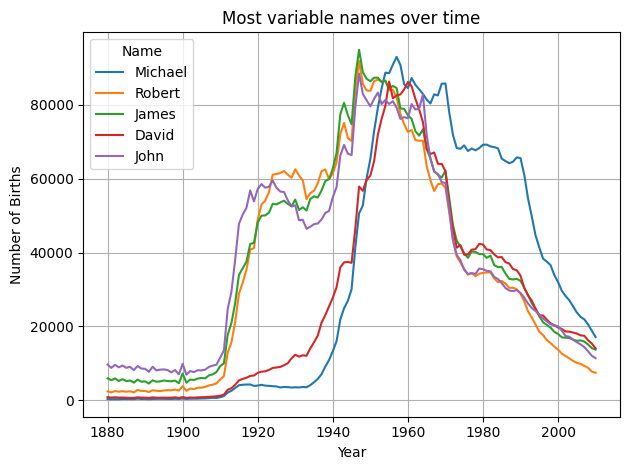

In [ ]:
name_changes = top1000.pivot_table("births", index="year", columns="name", aggfunc="sum").fillna(0)
variability = name_changes.var() # variance for each name (high var means number of births changes alot across the year)
top_changing_names = variability.sort_values(ascending=False).head(5)
print("Most variable names over time:\n", top_changing_names)


top_names_list = top_changing_names.index.tolist() #make name of these names to  list
top_names_data = name_changes[top_names_list]

top_names_data.plot(title="Most variable names over time", stacked=False)
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.grid(True)
plt.legend(title="Name")
plt.tight_layout()
plt.show()

# ***Gender-Neutral Names Analysis***

In [ ]:
neutral_names = names.groupby("name")["gender"].nunique()             #  number of unique names for both grnders
neutral_names = neutral_names[neutral_names == 2].index             #  بتعطينا قائمة الأسماء نفسها (بدون الأرقام).
neutral_data = names[names["name"].isin(neutral_names)]               # بنفلتر الداتا الأصلية names ونحتفظ فقط بالصفوف اللي اسمها موجود ضمن neutral_names.
print("Total number of gender-neutral names: ", len(neutral_names))
print("Some neutral names:",neutral_names.to_series().sample(3, random_state=42).tolist())

Total number of gender-neutral names:  9652
Some neutral names: ['Kailer', 'Lear', 'Aubra']


/tmp/ipython-input-68-1933461319.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neutral_counts.values, y=neutral_counts.index, palette="coolwarm")


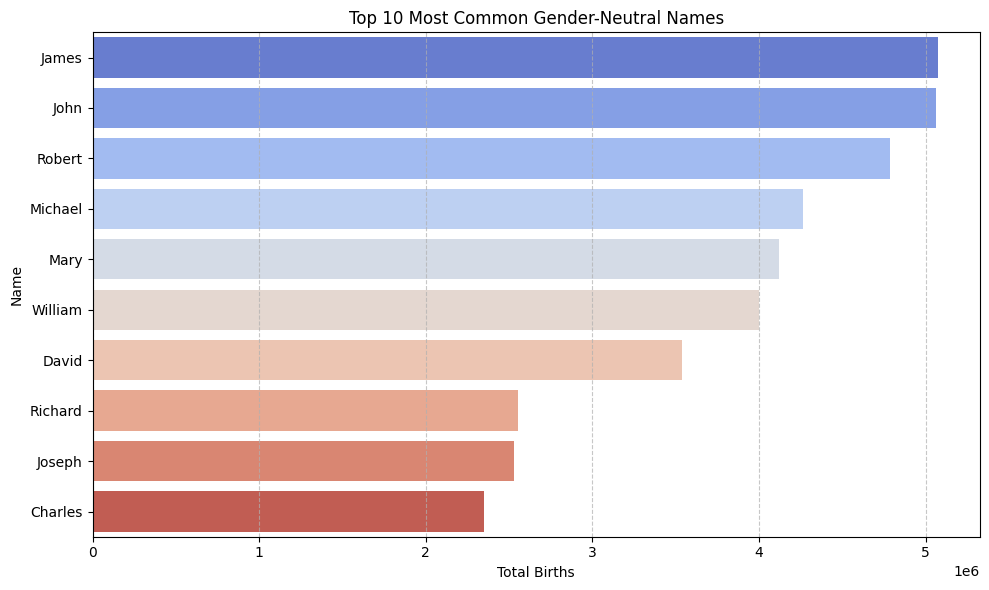

In [ ]:
# نحسب إجمالي عدد المواليد لكل اسم محايد
neutral_counts = neutral_data.groupby("name")["births"].sum().sort_values(ascending=False).head(10)

import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x=neutral_counts.values, y=neutral_counts.index, palette="coolwarm")

plt.title("Top 10 Most Common Gender-Neutral Names")
plt.xlabel("Total Births")
plt.ylabel("Name")
plt.tight_layout()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()